# Reservoir Computing for Connectome Networks I
## Task 1: Gaussian Random Network — Simulation & Visualization

**Rate model:**

$$\frac{dr_i}{dt} = -r_i + S\!\left[\sum_{j=1}^{N} W_{ij}\, r_j(t)\right], \qquad S(x) = \tanh(x)$$

**Gaussian random network:** $W_{ij} \sim \mathcal{N}\!\left(0,\; \frac{J^2}{N}\right)$

**Critical coupling:** $J_c = 1$


In [1]:
import numpy as np
import matplotlib.pyplot as plt


## 1. Core Functions

Each component of the simulation is split into its own function for clarity and reusability across future network architectures.


In [2]:
# ── Weight Matrix Generators ──

def generate_gaussian_weights(N: int, J: float, seed: int = None) -> np.ndarray:
    """
    Generate a Gaussian random connectivity matrix.
    
    Each element is drawn independently from N(0, J^2 / N), 
    so the network sits at the edge of chaos when J = 1.
    
    Parameters
    ----------
    N : int
        Number of neurons.
    J : float
        Coupling strength (critical value J_c = 1).
    seed : int, optional
        Random seed for reproducibility.
    
    Returns
    -------
    W : ndarray of shape (N, N)
        Recurrent connectivity matrix.
    """
    if seed is not None:
        np.random.seed(seed)
    
    sigma = J / np.sqrt(N)
    W = np.random.normal(loc=0.0, scale=sigma, size=(N, N))
    return W


In [3]:
# ── Initial Conditions ──

def initialize_rates(N: int, scale: float = 0.1, seed: int = None) -> np.ndarray:
    """
    Draw random initial firing rates from a small interval.
    
    Parameters
    ----------
    N : int
        Number of neurons.
    scale : float
        Half-width of the uniform interval [-scale, scale].
    seed : int, optional
        Random seed for reproducibility.
    
    Returns
    -------
    r0 : ndarray of shape (N,)
        Initial rate vector.
    """
    if seed is not None:
        np.random.seed(seed)
    
    return np.random.uniform(-scale, scale, size=N)


In [4]:
# ── Activation Function ──

def activation(x: np.ndarray) -> np.ndarray:
    """
    Sigmoidal nonlinearity S(x) = tanh(x).
    
    Maps the total incoming current to a bounded firing rate in (-1, 1).
    """
    return np.tanh(x)


In [5]:
# ── Euler Integration ──

def euler_step(r: np.ndarray, W: np.ndarray, dt: float) -> np.ndarray:
    """
    Advance the rate vector by one Euler step.
    
    Implements:  r(t + dt) = r(t) + dt * [-r(t) + S(W @ r(t))]
    
    Parameters
    ----------
    r : ndarray of shape (N,)
        Current rate vector.
    W : ndarray of shape (N, N)
        Connectivity matrix.
    dt : float
        Integration time step.
    
    Returns
    -------
    r_new : ndarray of shape (N,)
        Updated rate vector.
    """
    dr = -r + activation(W @ r)
    return r + dt * dr


def simulate(W: np.ndarray, r0: np.ndarray, dt: float, T: float) -> tuple:
    """
    Run a full Euler simulation of the rate model.
    
    Parameters
    ----------
    W : ndarray of shape (N, N)
        Connectivity matrix.
    r0 : ndarray of shape (N,)
        Initial rates.
    dt : float
        Time step.
    T : float
        Total simulation time.
    
    Returns
    -------
    t_arr : ndarray of shape (n_steps,)
        Time points.
    r_arr : ndarray of shape (n_steps, N)
        Rate trajectories for all neurons.
    """
    n_steps = int(T / dt)
    N = W.shape[0]
    
    r_arr = np.zeros((n_steps, N))
    r = r0.copy()
    
    for step in range(n_steps):
        r_arr[step] = r
        r = euler_step(r, W, dt)
    
    t_arr = np.arange(n_steps) * dt
    return t_arr, r_arr


## 2. Run Simulation

We choose $J > J_c = 1$ to observe chaotic activity.


In [6]:
# ── Parameters ──
N  = 500          # number of neurons
J  = 1.5          # coupling strength (> J_c = 1 for chaotic regime)
dt = 0.1          # Euler time step
T  = 100.0        # total simulation time

# ── Build network and initial conditions ──
W  = generate_gaussian_weights(N, J, seed=42)
r0 = initialize_rates(N, scale=0.1, seed=0)

# ── Simulate ──
t_arr, r_arr = simulate(W, r0, dt, T)

print(f"Simulated {N} neurons for T = {T} with dt = {dt}")
print(f"Trajectory shape: {r_arr.shape}  (time steps × neurons)")


Simulated 500 neurons for T = 100.0 with dt = 0.1
Trajectory shape: (1000, 500)  (time steps × neurons)


## 3. Plot 1 — Sampled Neuron Trajectories


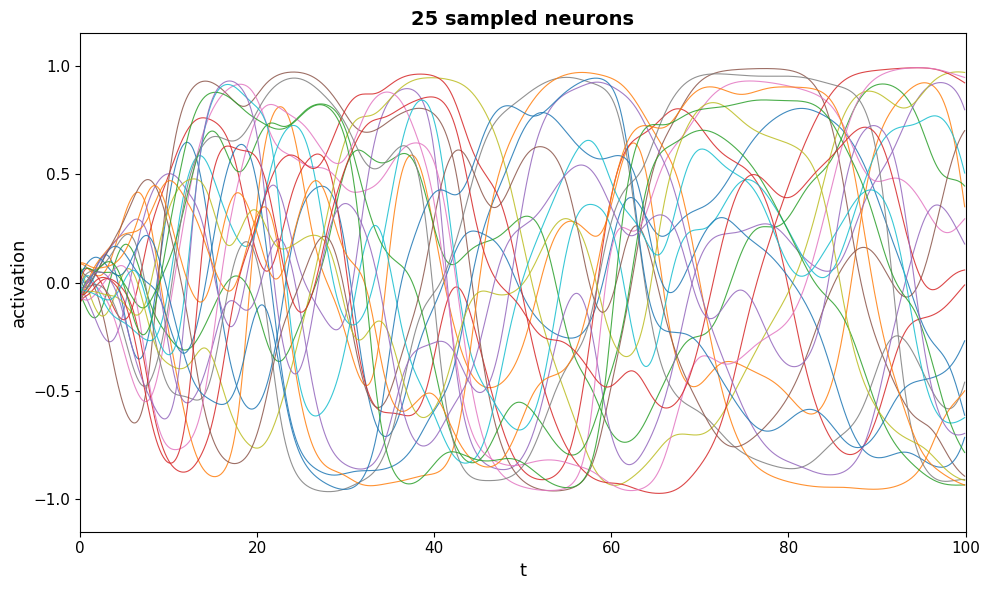

In [7]:
n_sample = 25

np.random.seed(7)
sample_idx = np.random.choice(N, size=n_sample, replace=False)

fig, ax = plt.subplots(figsize=(10, 6))

for i in sample_idx:
    ax.plot(t_arr, r_arr[:, i], linewidth=0.8, alpha=0.85)

ax.set_xlabel('t', fontsize=13)
ax.set_ylabel('activation', fontsize=13)
ax.set_title(f'{n_sample} sampled neurons', fontsize=14, fontweight='bold')
ax.set_xlim(0, T)
ax.set_ylim(-1.15, 1.15)
ax.tick_params(labelsize=11)
plt.tight_layout()
plt.show()


## 4. Plot 2 — Activation Histogram Over Time


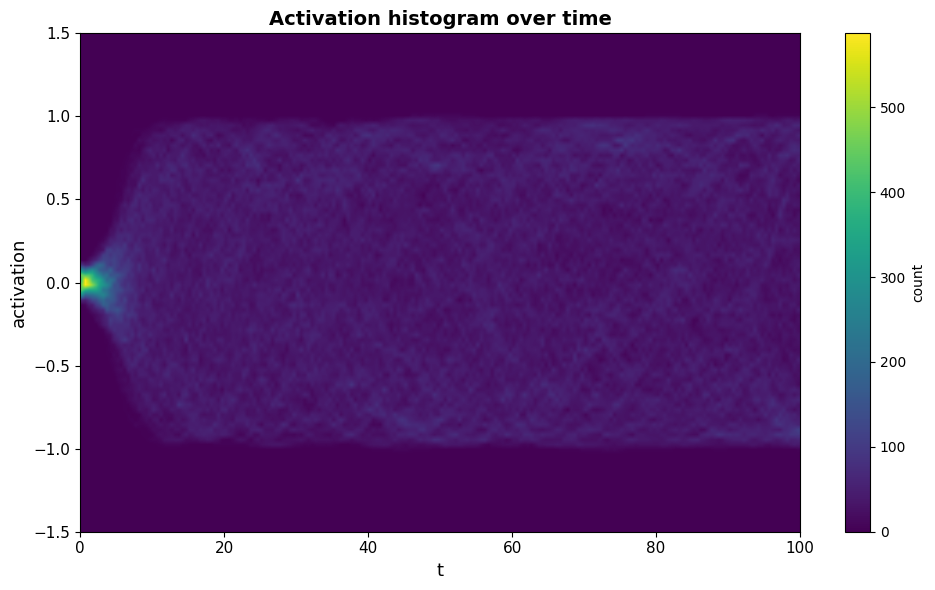

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

# Build 2D histogram: for each time bin, count how many neurons fall in each activation bin
n_time_bins = 200
n_act_bins  = 100
act_range   = (-1.5, 1.5)

# Subsample time to get bin edges
time_bin_edges = np.linspace(0, T, n_time_bins + 1)
act_bin_edges  = np.linspace(act_range[0], act_range[1], n_act_bins + 1)

# Flatten all (time, activation) pairs into a 2D histogram
t_indices = np.searchsorted(time_bin_edges, t_arr, side='right') - 1
t_indices = np.clip(t_indices, 0, n_time_bins - 1)

# Repeat time index for each neuron
t_flat = np.repeat(t_indices, N)
r_flat = r_arr.ravel()

hist, xedges, yedges = np.histogram2d(
    t_flat, r_flat,
    bins=[n_time_bins, n_act_bins],
    range=[[0, n_time_bins - 1], act_range]
)

# Map x-axis back to real time
extent = [0, T, act_range[0], act_range[1]]

im = ax.imshow(
    hist.T,
    origin='lower',
    aspect='auto',
    extent=extent,
    cmap='viridis',
    interpolation='bilinear'
)

cbar = fig.colorbar(im, ax=ax, label='count')
ax.set_xlabel('t', fontsize=13)
ax.set_ylabel('activation', fontsize=13)
ax.set_title('Activation histogram over time', fontsize=14, fontweight='bold')
ax.tick_params(labelsize=11)
plt.tight_layout()
plt.show()


## 5. Verification — Mean Temporal Variance vs $J$

From the guide: *compute the variance of $r_i(t)$ over time, then average over all $N$ neurons. This quantity is $> 0$ only for $J > J_c$.*


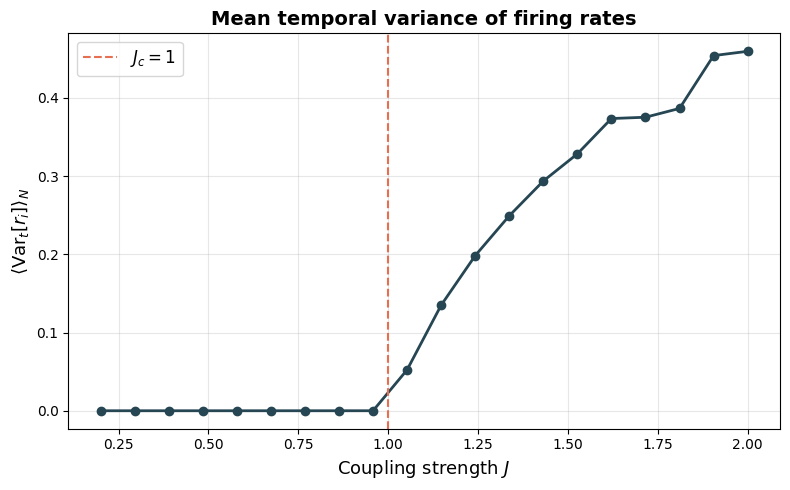

In [9]:
J_values = np.linspace(0.2, 2.0, 20)
mean_variances = []

for J_val in J_values:
    W_test  = generate_gaussian_weights(N, J_val, seed=42)
    r0_test = initialize_rates(N, scale=0.1, seed=0)
    t_test, r_test = simulate(W_test, r0_test, dt, T)
    
    # Discard transient (first 20% of time)
    transient = int(0.2 * len(t_test))
    r_steady = r_test[transient:]
    
    # Variance of each neuron over time, then average over neurons
    var_per_neuron = np.var(r_steady, axis=0)
    mean_variances.append(np.mean(var_per_neuron))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(J_values, mean_variances, 'o-', color='#264653', linewidth=2, markersize=6)
ax.axvline(x=1.0, color='#E76F51', linestyle='--', linewidth=1.5, label='$J_c = 1$')
ax.set_xlabel('Coupling strength $J$', fontsize=13)
ax.set_ylabel('$\\langle \\mathrm{Var}_t[r_i] \\rangle_N$', fontsize=13)
ax.set_title('Mean temporal variance of firing rates', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
